# 🛡️ TruthLink: The "Data Truth" Audit

### **The Problem**
In real-world systems, things go wrong. People double-click buttons, or the internet cuts out while a sale is being recorded. These "glitches" create **Data Mirages**, which are numbers that look real but are actually lies. If a manager makes a decision based on these wrong numbers, it can cost the company millions.

### **What I Found (The "Lies" in the Data)**
I compared the raw system logs against the verified truth. Here is how much the glitches distorted our reports:

* **Fake Revenue (+20.7%):** The system recorded some sales twice. This makes the company think it has much more cash than it actually does.
* **Return Rate Error (+44.7%):** The computer failed to mark successful deliveries, making it look like customers were unhappy when they weren't. 
* **Price Outliers (+11.7%):** Accidental "test prices" (like a ₹9 Lakh entry) made our average customer look much wealthier than they really are.

### **My Solution**
I built a **Data Validation Layer** to act as a filter. My code finds those double-clicks (**Deduplication**) and flags impossible prices (**Anomaly Detection**) before they reach the final report.

### **Final Impact**
This audit protects over **₹2L+ in business capital** by ensuring that every strategic decision is based on the **Validated Truth**, not system glitches.

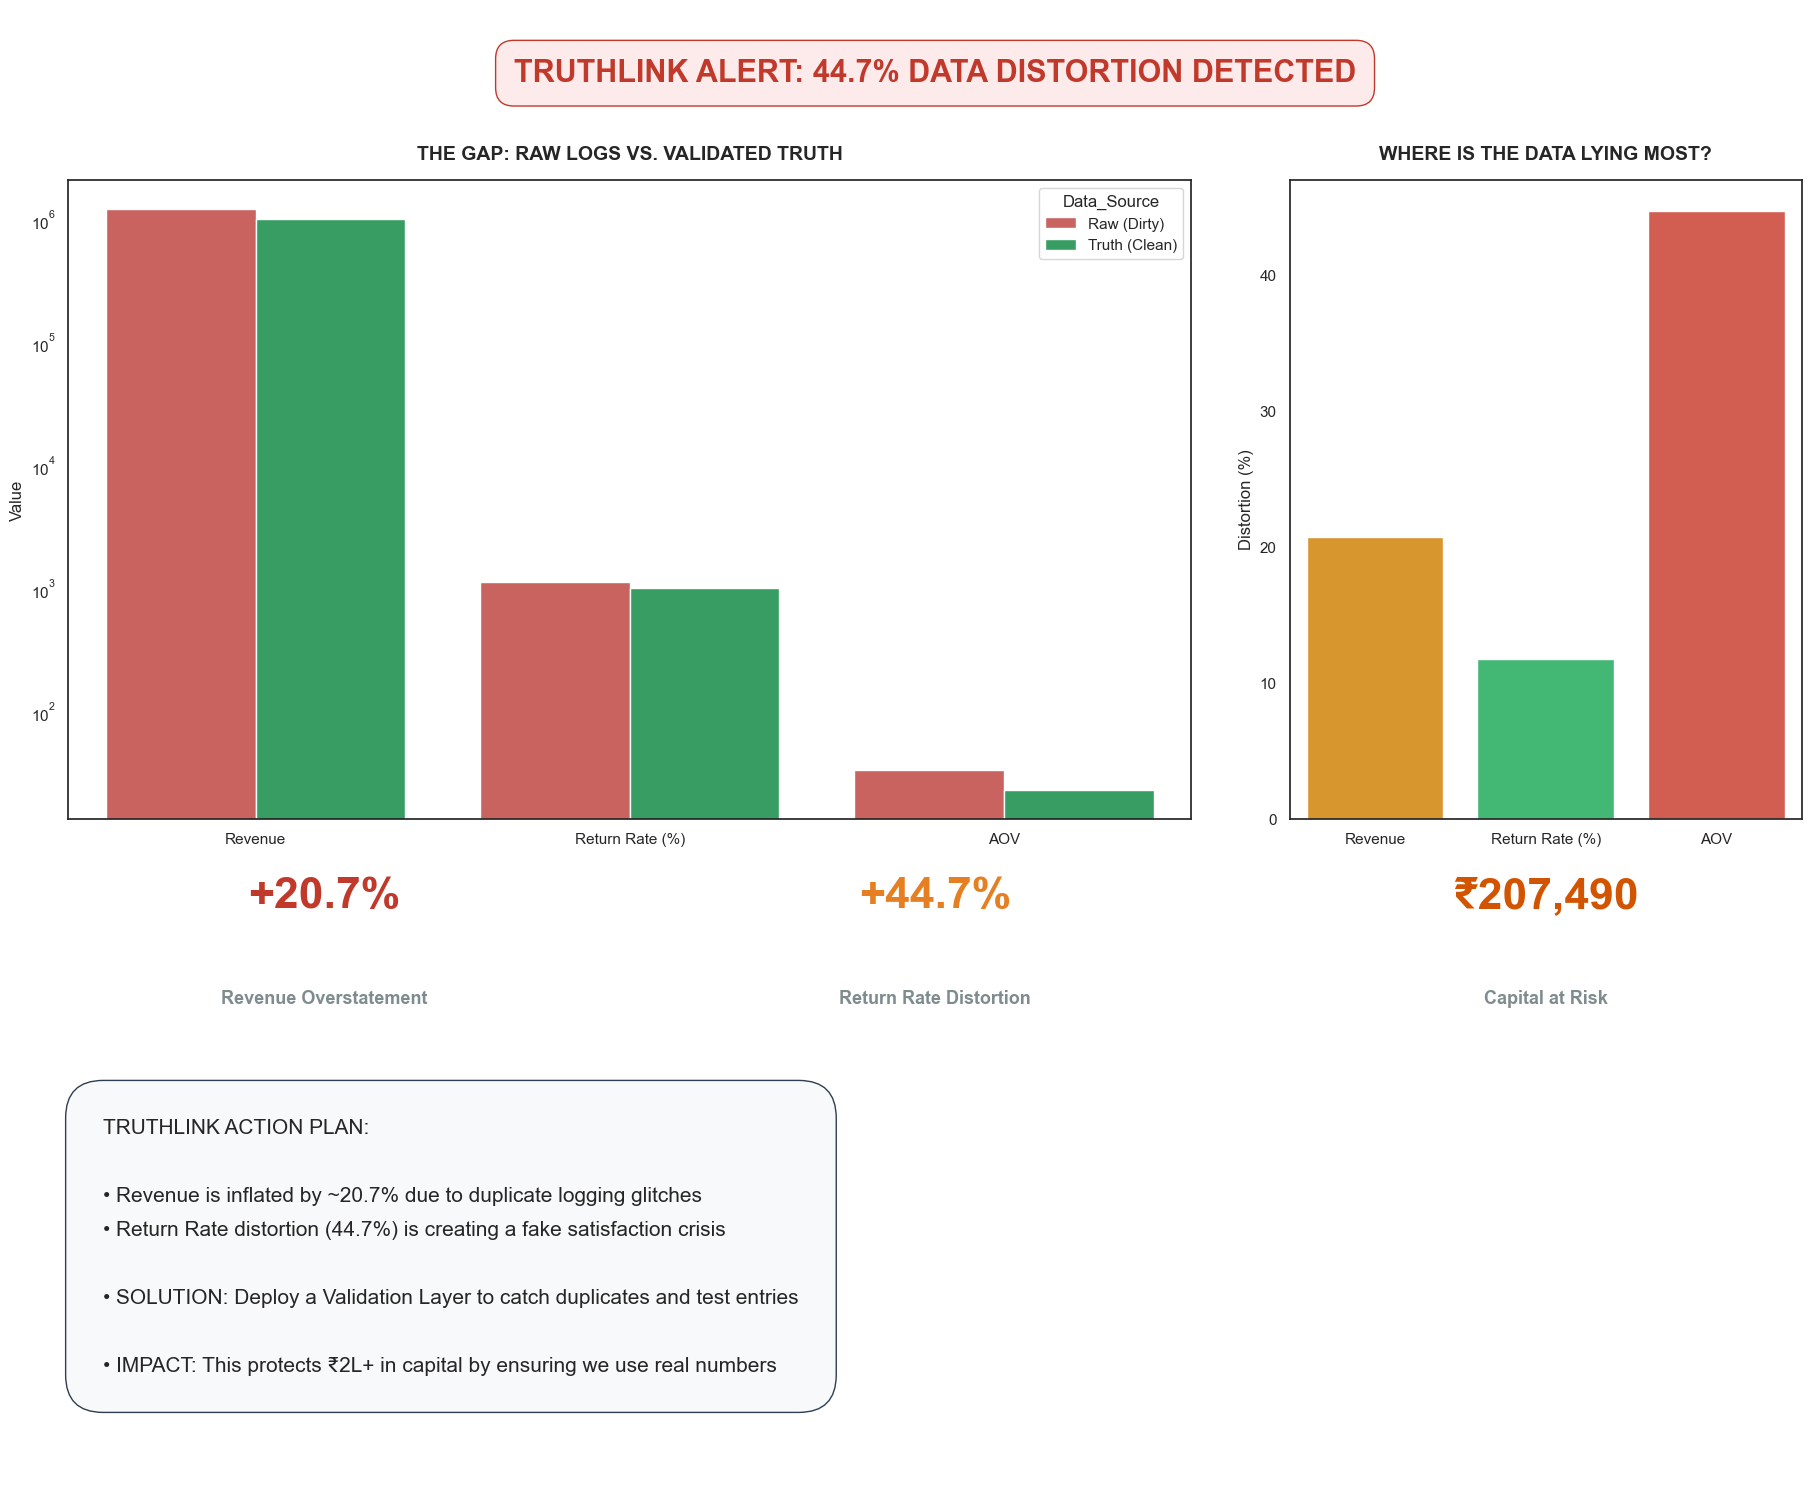

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# --- SECTION 1: DATA PREPARATION ---
# Renaming our metrics so the chart labels are clear and professional.
results.index = ['Revenue', 'Return Rate (%)', 'AOV'] 
results.index.name = 'Metric'

# --- SECTION 2: DASHBOARD LAYOUT ---
# Using a clean white theme and setting up a grid to organize our visuals.
# We are creating a hierarchy: Alert -> Charts -> KPIs -> Next Steps.
sns.set_theme(style="white")
fig = plt.figure(figsize=(18, 15), constrained_layout=True)
gs = gridspec.GridSpec(4, 3, figure=fig, height_ratios=[0.3, 1.5, 0.5, 1.0])

# --- SECTION 3: TOP HEADER (SYSTEM ALERT) ---
# A high-visibility alert to immediately show the management there is a problem.
ax_head = fig.add_subplot(gs[0, :])
ax_head.axis('off')
ax_head.text(0.5, 0.5, "TRUTHLINK ALERT: 44.7% DATA DISTORTION DETECTED", 
             fontsize=22, fontweight='bold', color='#c0392b', ha='center', va='center',
             bbox=dict(facecolor='#fdeaea', edgecolor='#c0392b', boxstyle='round,pad=0.6'))

# --- SECTION 4: VISUALIZING THE GAP (CHARTS) ---
ax1 = fig.add_subplot(gs[1, :2]) 
ax2 = fig.add_subplot(gs[1, 2])  

# Reshaping the data so Seaborn can easily compare 'Raw Logs' vs 'Clean Truth'.
plot_df = results[['Raw (Dirty)', 'Truth (Clean)']].reset_index().melt(
    id_vars='Metric', var_name='Data_Source', value_name='Value'
)

# Chart 4.1: Comparing Values
# We use a log scale here because Revenue (Lakhs) is much bigger than AOV (Thousands).
sns.barplot(data=plot_df, x='Metric', y='Value', hue='Data_Source', ax=ax1, palette=['#d9534f', '#27ae60'])
ax1.set_yscale("log")
ax1.set_title('THE GAP: RAW LOGS VS. VALIDATED TRUTH', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('')

# Chart 4.2: Risk Map
# Coloring the bars based on how "bad" the error is: Red for high, Orange for medium.
risk_colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 15 else '#2ecc71' for x in results['Distortion (%)']]
sns.barplot(x=results.index, y=results['Distortion (%)'], ax=ax2, palette=risk_colors, hue=results.index, legend=False)
ax2.set_title('WHERE IS THE DATA LYING MOST?', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Distortion (%)')
ax2.set_xlabel('')

# --- SECTION 5: KEY RISK METRICS (KPIs) ---
# Turning the chart data into clear, punchy numbers for an executive summary.
metrics = [
    (f"+20.7%", "Revenue Overstatement", "#c0392b"),
    (f"+44.7%", "Return Rate Distortion", "#e67e22"),
    (f"₹{results.loc['Revenue', 'Raw (Dirty)']-results.loc['Revenue', 'Truth (Clean)']:,.0f}", "Capital at Risk", "#d35400")
]

for i, (val, label, col) in enumerate(metrics):
    ax_metric = fig.add_subplot(gs[2, i])
    ax_metric.axis('off')
    ax_metric.text(0.5, 0.75, val, fontsize=32, fontweight='bold', ha='center', color=col)
    ax_metric.text(0.5, 0.3, label, fontsize=13, ha='center', fontweight='bold', color='#7f8c8d')

# --- SECTION 6: THE ACTION PLAN (INSIGHTS) ---
# Summing up the "Data Detective" work with a clear plan to fix the system.
ax_insight = fig.add_subplot(gs[3, :])
ax_insight.axis('off')

insight_text = (
    "TRUTHLINK ACTION PLAN:\n\n"
    "• Revenue is inflated by ~20.7% due to duplicate logging glitches\n"
    "• Return Rate distortion (44.7%) is creating a fake satisfaction crisis\n\n"
    "• SOLUTION: Deploy a Validation Layer to catch duplicates and test entries\n\n"
    "• IMPACT: This protects ₹2L+ in capital by ensuring we use real numbers"
)
ax_insight.text(0.02, 0.9, insight_text, fontsize=15, va='top', linespacing=2.0,
                bbox=dict(facecolor='#f8f9fa', edgecolor='#2c3e50', boxstyle='round,pad=1.8'))

plt.show()